In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast
import matplotlib.ticker as ticker
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filter for Data Analyst Roles in the United Kingdom

In [2]:
df_DA_UK = df[(df['job_country'] == 'United Kingdom') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA_UK.info()

<class 'pandas.DataFrame'>
Index: 10482 entries, 74 to 785485
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        10482 non-null  str           
 1   job_title              10482 non-null  str           
 2   job_location           10481 non-null  str           
 3   job_via                10482 non-null  str           
 4   job_schedule_type      10321 non-null  str           
 5   job_work_from_home     10482 non-null  bool          
 6   search_location        10482 non-null  str           
 7   job_posted_date        10482 non-null  datetime64[us]
 8   job_no_degree_mention  10482 non-null  bool          
 9   job_health_insurance   10482 non-null  bool          
 10  job_country            10482 non-null  str           
 11  salary_rate            73 non-null     str           
 12  salary_year_avg        72 non-null     float64       
 13  salary_hour_avg

Text(0, 0.5, '')

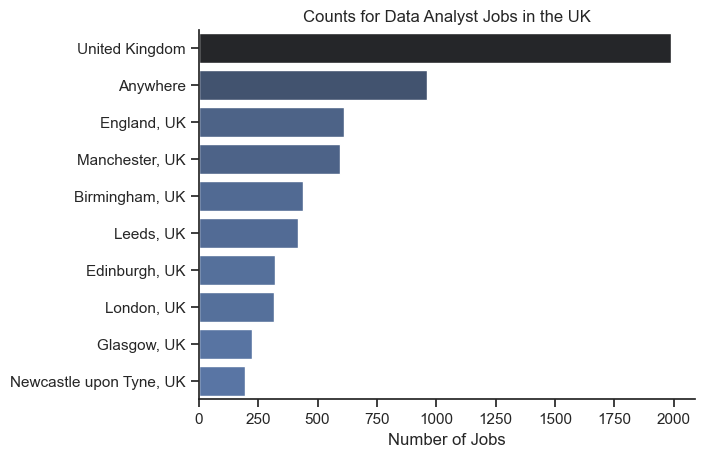

In [6]:
df_plot = df_DA_UK['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts for Data Analyst Jobs in the UK')
plt.xlabel('Number of Jobs')
plt.ylabel('')

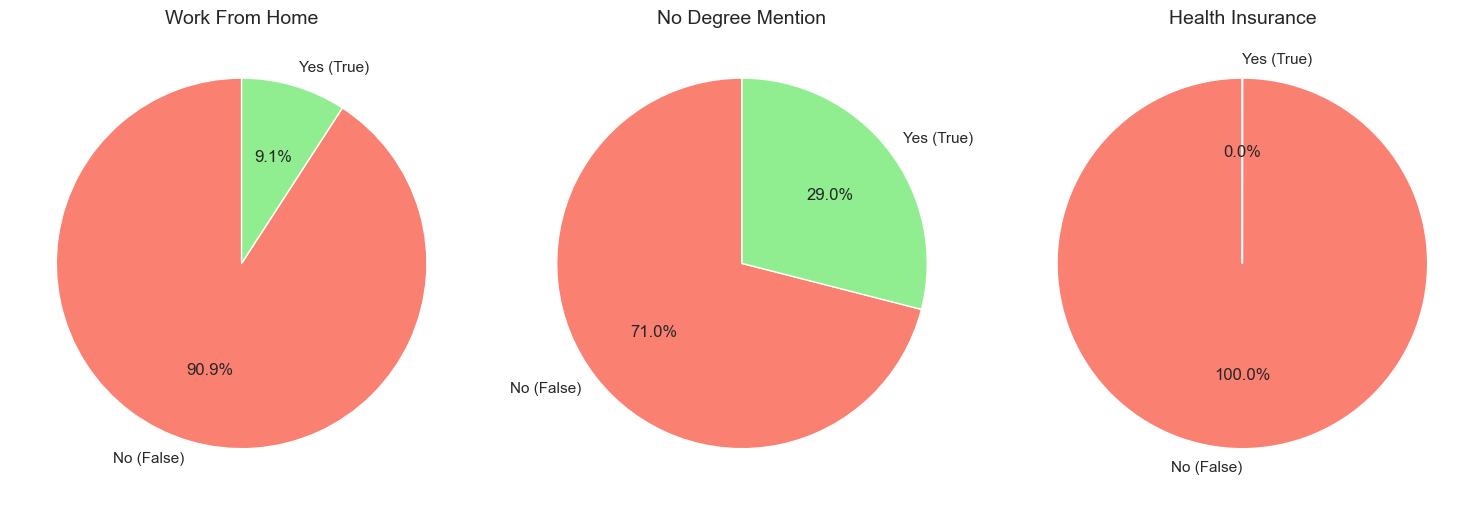

In [7]:
# Considering the columns that provide boolean values
# Plot different subplots as pie charts

# Create list of columns to analyze
columns = ['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(columns):
    # Get value counts (True and False)
    counts = df_DA_UK[col].value_counts()
    
    # Create pie chart with True as green, False as salmon/red
    axes[i].pie(counts, labels=['No (False)', 'Yes (True)'], autopct='%1.1f%%', 
                colors=['salmon', 'lightgreen'], startangle=90)
    axes[i].set_title(col.replace('job_', '').replace('_', ' ').title(), fontsize=14)

plt.tight_layout()
plt.show()

Text(0, 0.5, '')

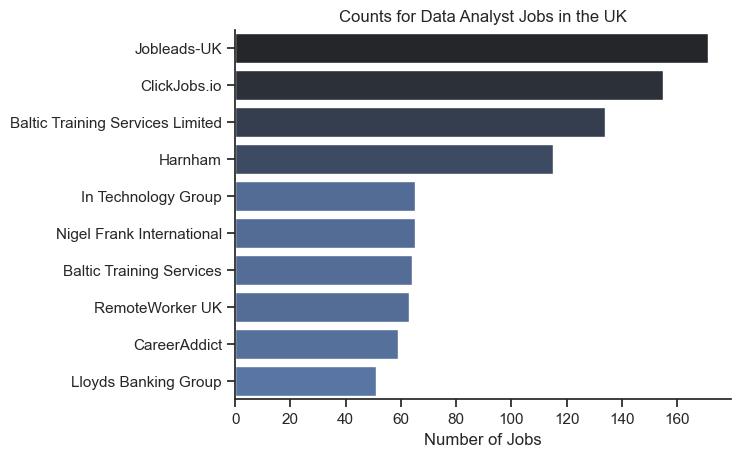

In [8]:
#Analysis of the major companies offering Data Analyst jobs
df_plot = df_DA_UK['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts for Data Analyst Jobs in the UK')
plt.xlabel('Number of Jobs')
plt.ylabel('')